# 5.0: Probability Calibration

**Question this notebook answers:** can the predicted probabilities from the final model
be read as real probabilities of default, and did an attempt to recalibrate a
less-well-calibrated candidate actually pay off?

This notebook scores the already-serialized final models on the test set to draw a fresh
reliability diagram (inference only). The recalibration *experiment* itself
(`notebooks/11_calibration.ipynb`) fit a Platt/isotonic calibrator on a temporal holdout
inside the training years. That experiment is narrated from `docs/FACTS.md` below, not
re-run (re-running it would retrain a second model on a subset of the data, which this
notebook deliberately avoids).

In [1]:
import sys, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

sys.path.insert(0, str(Path('..').resolve()))
from src.data import load_split, FEATURE_SET, CATEGORICAL_COLS
from src.features import build_features, prepare_X

train = load_split('train')
test = load_split('test')
X_train = prepare_X(build_features(train), FEATURE_SET, CATEGORICAL_COLS)
test_feat = build_features(test)
X_test = prepare_X(test_feat, FEATURE_SET, CATEGORICAL_COLS).reindex(columns=X_train.columns, fill_value=0)
y_test = test_feat['target'].values

xgb_final = joblib.load(Path('..') / 'models' / 'xgb_final.joblib')
m1_final = joblib.load(Path('..') / 'models' / 'logistic_baseline.joblib')

y_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]
y_prob_m1 = m1_final.predict_proba(X_test)[:, 1]

brier_xgb = brier_score_loss(y_test, y_prob_xgb)
brier_m1 = brier_score_loss(y_test, y_prob_m1)
print(f'Brier score, XGB_walkforward (test 2015): {brier_xgb:.4f}  (docs/FACTS.md: 0.1205)')
print(f'Brier score, M1 (test 2015):              {brier_m1:.4f}  (docs/FACTS.md: 0.1210)')


Brier score, XGB_walkforward (test 2015): 0.1205  (docs/FACTS.md: 0.1205)
Brier score, M1 (test 2015):              0.1210  (docs/FACTS.md: 0.1210)


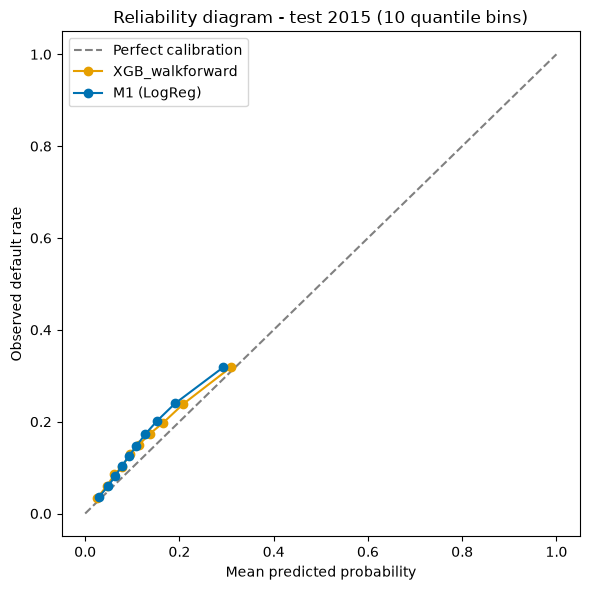

In [2]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
for name, y_prob, color in [('XGB_walkforward', y_prob_xgb, '#E69F00'), ('M1 (LogReg)', y_prob_m1, '#0072B2')]:
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name, color=color)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed default rate')
ax.set_title('Reliability diagram - test 2015 (10 quantile bins)')
ax.legend()
plt.tight_layout()
plt.show()


Both curves track the diagonal reasonably closely. Neither model is dramatically
over- or under-confident on the 2015 test set. This is a live check, computed on the
shipped model. The decision about *which* model needed recalibration, and whether it was
worth it, was made earlier, on the 2014 validation year, and is narrated next from
`docs/FACTS.md` / `notebook 11`.

## The recalibration experiment (validation year, 2014, not re-run here)

`notebook 11` measured calibration on the **validation** year for three candidates via
Murphy's reliability decomposition (lower = better-calibrated):

| Model | Reliability (validation 2014) |
|---|---|
| **XGB_walkforward** (the model that shipped) | **0.000235 - best of the three** |
| M1 (LogReg) | 0.000237 |
| XGB_tuned (single-window winner from `notebook 09`) | 0.000333 - worst |

The surprising result: **the model that ultimately shipped was already the best-calibrated
of the three, without any recalibration.** The worst-calibrated candidate,
`XGB_tuned`, was the one selected for a recalibration experiment.

## Recalibrating the worse candidate: isotonic regression

Recalibrating `XGB_tuned` required a base model trained on `issue_d <= 2012` only, with
the calibrator (isotonic) fit on the held-out 2013 slice, a legitimate temporal holdout,
never touching validation or test. The result: reliability improved sharply, from
**0.001142 to 0.000095**, the best-calibrated model in the entire study.

## ...and its real cost

The base model behind that recalibration was trained on **42% less data** (72,566 rows
instead of 172,988, since 2013 was reserved for the calibrator rather than for training).
Validation-year profit for the calibrated model came out to **$189,851,160**, barely
above the approve-everyone baseline (~$189.7M on that same validation year), and well
below the $190-191M range the uncalibrated candidates achieved.

**Recalibration cost more than it gained here.** The reliability metric improved, but the
business metric this project optimizes for (profit) got worse, because achieving that
calibration required giving up nearly half the training data. This is why the shipped
model is the uncalibrated `XGB_walkforward`, not a recalibrated variant: it was already
better-calibrated than the alternative that recalibration was tried on, and the
recalibration trade-off measured directly against the one candidate that needed it did
not pay for itself.

## Takeaway

Calibration and discrimination (AUC) are different questions, and so are calibration and
profit. The model that shipped needed no recalibration. It was already the
best-calibrated of the three candidates measured. The one experiment that *did*
recalibrate a model produced a textbook-good reliability number and a worse profit,
because the calibration procedure's data cost (a smaller, older training set) outweighed
its statistical benefit. That asymmetry, a metric improving while the metric that
matters gets worse, is the same shape as the central finding of `6.0`.

**Next:** `6.0-evaluation.ipynb`: the test-set result, reported as profit first and AUC
second, plus the subgroup and transfer analyses that qualify how far the model can be
trusted.